Titanic Dataset – Survival Analysis
 Data Science with Python Internship – Task 2

**Goal:** Clean the Titanic dataset, answer key survival questions, and visualize the patterns using Pandas, Matplotlib and Seaborn.

**Sections:**
1. Load the data
2. Explore & clean the data (handle missing values)
3. Answer business questions (gender, class, age group)
4. Visualizations (gender, class, age histogram)
5. Summary of insights

1. Load the Titanic Dataset
The dataset is the classic Kaggle Titanic `train.csv` (891 passengers, 12 columns).

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [3]:
df.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


2. Clean the Data

We check for missing values and handle them:
- **Age**: ~20% missing → fill with the **median age** (robust to outliers).
- **Cabin**: ~77% missing → too sparse to be useful, so we drop the column.
- **Embarked**: only 2 missing → fill with the **mode** (most common port).
- **Fare**: no missing values here, but we check anyway.


In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df_clean = df.copy()

df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])
df_clean.drop(columns=["Cabin"], inplace=True)

bins = [0, 12, 18, 35, 60, 100]
labels = ["Child", "Teen", "Young Adult", "Adult", "Senior"]
df_clean["AgeGroup"] = pd.cut(df_clean["Age"], bins=bins, labels=labels)

df_clean.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
AgeGroup       0
dtype: int64

3. Answer the Business Questions

Q1: Who survived more — males or females?

In [6]:
df_clean.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

**Answer:** Females survived at a much higher rate than males. Roughly **3 out of 4 women** survived, compared to only about **1 in 5 men**. This reflects the historical "women and children first" evacuation policy during the disaster.

Q2: Did passenger class affect survival chances?

In [7]:
df_clean.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

**Answer:** Yes — survival rate drops sharply as class number increases. **1st class passengers** survived roughly **63%** of the time, **2nd class** around **47%**, while **3rd class** passengers survived only about **24%** of the time. Wealthier passengers had cabins closer to the deck and easier access to lifeboats.

Q3: What was the survival rate by age group?

In [8]:
df_clean.groupby("AgeGroup", observed=True)["Survived"].mean()

AgeGroup
Child          0.579710
Teen           0.428571
Young Adult    0.353271
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64

**Answer:** **Children (0-12)** had the highest survival rate of all age groups (consistent with "children first"), while **Adults (36-60)** and **Young Adults (19-35)** had noticeably lower survival rates. This again lines up with the evacuation priority given to children.

Bonus: Combined effect of gender and class

In [9]:
df_clean.groupby(["Pclass", "Sex"])["Survived"].mean().unstack()

Sex,female,male
Pclass,,
1,0.968085,0.368852
2,0.921053,0.157407
3,0.500000,0.135447


**Insight:** The gap is starkest for men — a 1st class man (≈37% survival) was over **5x** more likely to survive than a 3rd class man (≈14%). Women had high survival rates across all classes, but it was still highest in 1st class (≈97%).

4. Visualizations

4.1 Survival by Gender

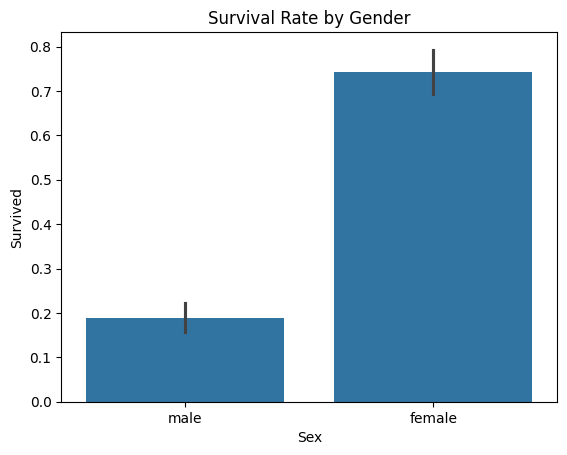

In [10]:
sns.barplot(x="Sex", y="Survived", data=df_clean)
plt.title("Survival Rate by Gender")
plt.show()

**Insight:** Female passengers survived at roughly 3-4x the rate of male passengers.

4.2 Survival by Passenger Class

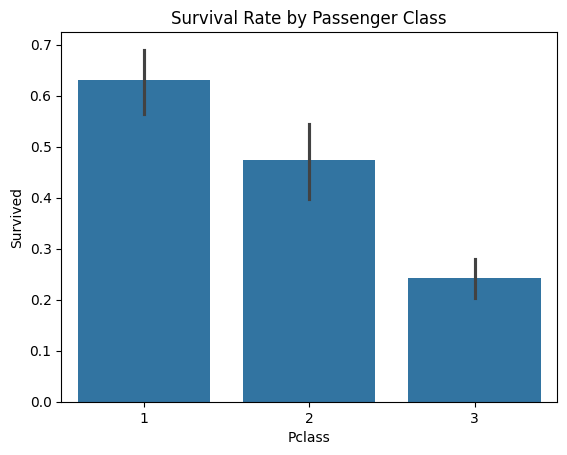

In [11]:
sns.barplot(x="Pclass", y="Survived", data=df_clean)
plt.title("Survival Rate by Passenger Class")
plt.show()

**Insight:** Survival rate decreases steadily from 1st to 3rd class, showing a clear link between socio-economic status and survival.

4.3 Histogram of Passenger Ages

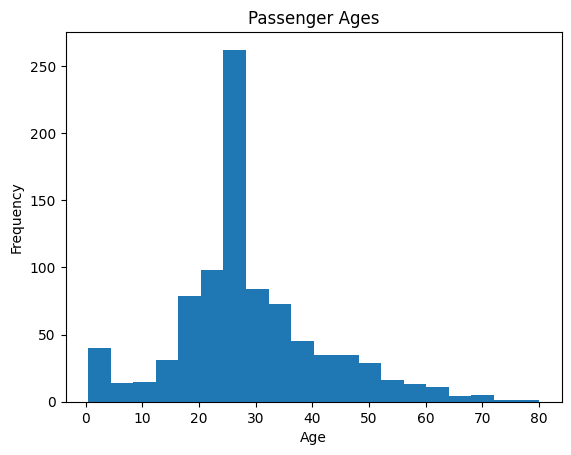

In [12]:
df_clean["Age"].plot(kind="hist", bins=20, title="Passenger Ages")
plt.xlabel("Age")
plt.show()

**Insight:** Most passengers were young adults between roughly 20-40 years old. There's a smaller bump of children/infants, and very few passengers over 60.

4.4 Bonus: Survival Rate by Age Group

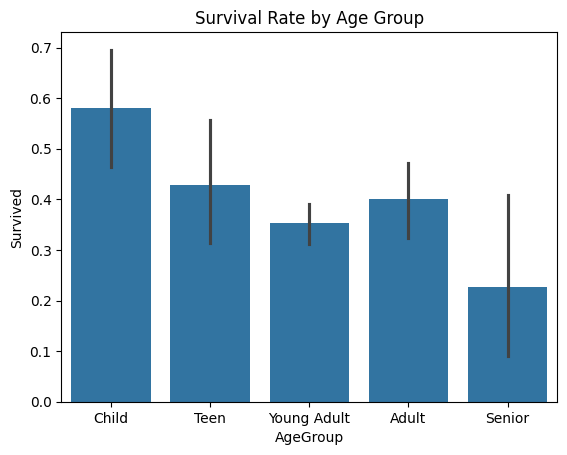

In [13]:
sns.barplot(x="AgeGroup", y="Survived", data=df_clean)
plt.title("Survival Rate by Age Group")
plt.show()

**Insight:** Children had the best survival odds of any age group, supporting the historical accounts of children being prioritized during evacuation.

5. Summary of Insights

Gender mattered most.** Women survived at roughly 3-4x the rate of men (~74% vs ~19%), consistent with "women and children first" evacuation priority.
Class mattered a lot.** First-class passengers survived about 2.5x more often than third-class passengers (~63% vs ~24%), reflecting better access to lifeboats and cabin location.
Children had an edge.** The Child (0-12) age group had the highest survival rate of any age bracket.
Gender and class compound.** A first-class woman had a near-certain chance of survival (~97%), while a third-class man had the worst odds of any group (~14%).

These patterns highlight how both social status and demographic factors shaped survival chances during the Titanic disaster.